# FakeLens 360 — XLM-RoBERTa multilingue final

Ce notebook fusionne automatiquement les exports standardisés de LIAR, AFND et FakeNewsNet. Il supprime les fuites textuelles entre splits, équilibre la contribution des datasets et entraîne un modèle commun anglais/arabe.

In [2]:
!pip install -q transformers datasets accelerate evaluate sentencepiece scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path
import json, random, re, unicodedata
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding,
    EarlyStoppingCallback, Trainer, TrainingArguments,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
PROJECT_ROOT = Path('/content/drive/MyDrive/FakeNewsDetection')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models' / 'xlmr_multilingual'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'xlmr_multilingual'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MAX_TRAIN_PER_DATASET = 20000
MAX_VALID_PER_DATASET = 5000
MAX_TEST_PER_DATASET = 5000
print('GPU disponible :', torch.cuda.is_available())
if not torch.cuda.is_available():
    print('Active GPU : Exécution > Modifier le type d’exécution > T4 GPU')

GPU disponible : True


## 1. Chargement des exports standardisés

In [5]:
required = ['text', 'label_binary', 'dataset', 'language', 'split']
frames = []
for path in sorted(PROCESSED_DIR.glob('*_standardized.csv')):
    df = pd.read_csv(path)
    missing = set(required) - set(df.columns)
    if missing:
        print('Ignoré :', path.name, '| colonnes manquantes :', missing)
        continue
    frames.append(df[required].copy())
    print(path.name, len(df))

if not frames:
    raise FileNotFoundError('Aucun export standardisé. Exécute d’abord les notebooks LIAR, AFND et FakeNewsNet.')

all_data = pd.concat(frames, ignore_index=True)
all_data = all_data.dropna(subset=['text', 'label_binary']).copy()
all_data = all_data[all_data['label_binary'].isin(['FAKE', 'REAL'])]
all_data['text'] = all_data['text'].astype(str).str.strip()
all_data = all_data[all_data['text'].str.len() >= 5]
display(all_data.groupby(['dataset', 'split', 'label_binary']).size().unstack(fill_value=0))

afnd_test_standardized.csv 6608
afnd_train_standardized.csv 33605
afnd_valid_standardized.csv 7869
fakenewsnet_test_standardized.csv 3239
fakenewsnet_train_standardized.csv 15115
fakenewsnet_valid_standardized.csv 3239
liar_test_standardized.csv 1267
liar_train_standardized.csv 10240
liar_valid_standardized.csv 1284


label_binary        FAKE   REAL
dataset     split              
AFND        test    2794   2586
            train  12259  13043
            valid   2672   3197
FakeNewsNet test     780   2459
            train   3638  11477
            valid    779   2460
LIAR        test     553    449
            train   4488   3638
            valid    616    420

## 2. Suppression des doublons et fuites entre datasets

In [6]:
def norm(text):
    text = unicodedata.normalize('NFKC', str(text)).lower().strip()
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

all_data['text_norm'] = all_data['text'].map(norm)
# Retirer les textes identiques portant des labels contradictoires.
conflicts = all_data.groupby('text_norm')['label_binary'].nunique()
conflicting_texts = set(conflicts[conflicts > 1].index)
all_data = all_data[~all_data['text_norm'].isin(conflicting_texts)].copy()

# Priorité au train, puis valid, puis test : un texte ne peut survivre que dans le premier split rencontré.
priority = pd.Categorical(all_data['split'], categories=['train', 'valid', 'test'], ordered=True)
all_data = all_data.assign(_priority=priority).sort_values('_priority')
all_data = all_data.drop_duplicates('text_norm', keep='first').drop(columns='_priority')

for a, b in [('train', 'valid'), ('train', 'test'), ('valid', 'test')]:
    overlap = len(set(all_data.loc[all_data.split == a, 'text_norm']) & set(all_data.loc[all_data.split == b, 'text_norm']))
    print(f'{a} ↔ {b}: {overlap} texte(s) commun(s)')

train ↔ valid: 0 texte(s) commun(s)
train ↔ test: 0 texte(s) commun(s)
valid ↔ test: 0 texte(s) commun(s)


## 3. Équilibrage par dataset et classe

In [7]:
def cap_group(group, limit):
    return group.sample(min(len(group), limit), random_state=SEED)

caps = {'train': MAX_TRAIN_PER_DATASET, 'valid': MAX_VALID_PER_DATASET, 'test': MAX_TEST_PER_DATASET}
parts = []
for (dataset_name, split_name, label), group in all_data.groupby(['dataset', 'split', 'label_binary']):
    per_class_limit = max(1, caps[split_name] // 2)
    parts.append(cap_group(group, per_class_limit))
balanced = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

display(balanced.groupby(['dataset', 'split', 'label_binary']).size().unstack(fill_value=0))
balanced.to_csv(RESULTS_DIR / 'multilingual_training_manifest.csv', index=False)

label_binary        FAKE   REAL
dataset     split              
AFND        test    2500   2500
            train  10000  10000
            valid   2500   2500
FakeNewsNet test     780   2459
            train   3638  10000
            valid    779   2460
LIAR        test     551    448
            train   4480   3635
            valid    612    419

## 4. Création du DatasetDict

In [8]:
label2id = {'FAKE': 0, 'REAL': 1}
id2label = {0: 'FAKE', 1: 'REAL'}
balanced['label'] = balanced['label_binary'].map(label2id)

dataset_dict = DatasetDict()
for split_name in ['train', 'valid', 'test']:
    part = balanced[balanced.split == split_name][['text', 'label', 'dataset', 'language']].copy()
    if part.empty:
        raise ValueError(f'Split vide : {split_name}')
    dataset_dict[split_name] = Dataset.from_pandas(part, preserve_index=False)
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'dataset', 'language'],
        num_rows: 41753
    })
    valid: Dataset({
        features: ['text', 'label', 'dataset', 'language'],
        num_rows: 9270
    })
    test: Dataset({
        features: ['text', 'label', 'dataset', 'language'],
        num_rows: 9238
    })
})

## 5. Tokenisation XLM-RoBERTa

In [9]:
MODEL_NAME = 'xlm-roberta-base'
MAX_LENGTH = 192
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

tokenized = dataset_dict.map(tokenize, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/41753 [00:00<?, ? examples/s]

Map:   0%|          | 0/9270 [00:00<?, ? examples/s]

Map:   0%|          | 0/9238 [00:00<?, ? examples/s]

## 6. Entraînement

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, pred, average='macro', zero_division=0)
    return {
        'accuracy': accuracy_score(labels, pred),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, label2id=label2id, id2label=id2label
)

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    weight_decay=0.01,
    warmup_ratio=0.10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['valid'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)
trainer.train()

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.865152,0.733923,0.717368,0.714277,0.719526,0.714394
2,0.756363,0.757389,0.729234,0.722168,0.718056,0.719650


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5220, training_loss=0.9185536527085578, metrics={'train_runtime': 1296.542, 'train_samples_per_second': 64.407, 'train_steps_per_second': 4.026, 'total_flos': 8158938160075680.0, 'train_loss': 0.9185536527085578, 'epoch': 2.0})

## 7. Évaluation globale et par dataset

In [11]:
output = trainer.predict(tokenized['test'])
pred_ids = np.argmax(output.predictions, axis=1)
proba = torch.softmax(torch.tensor(output.predictions), dim=1).numpy()
confidence = proba.max(axis=1)

test_df = balanced[balanced.split == 'test'].reset_index(drop=True).copy()
test_df['prediction'] = [id2label[i] for i in pred_ids]
test_df['confidence'] = confidence

global_metrics = compute_metrics((output.predictions, output.label_ids))
display(pd.DataFrame([global_metrics]))

rows = []
for dataset_name, group in test_df.groupby('dataset'):
    rows.append({
        'dataset': dataset_name,
        'n': len(group),
        'accuracy': accuracy_score(group.label_binary, group.prediction),
        'f1_macro': f1_score(group.label_binary, group.prediction, average='macro', zero_division=0),
        'confidence_moyenne': group.confidence.mean(),
    })
per_dataset = pd.DataFrame(rows).sort_values('f1_macro', ascending=False)
display(per_dataset)

pd.DataFrame([global_metrics]).to_csv(RESULTS_DIR / 'xlmr_global_metrics.csv', index=False)
per_dataset.to_csv(RESULTS_DIR / 'xlmr_metrics_by_dataset.csv', index=False)

,accuracy,precision_macro,recall_macro,f1_macro
0,0.648842,0.644679,0.648586,0.644369


,dataset,n,accuracy,f1_macro,confidence_moyenne
1,FakeNewsNet,3239,0.853967,0.795490,0.890596
2,LIAR,999,0.642643,0.632495,0.694931
0,AFND,5000,0.517200,0.511714,0.882275


## 8. Matrice de confusion, erreurs et abstention

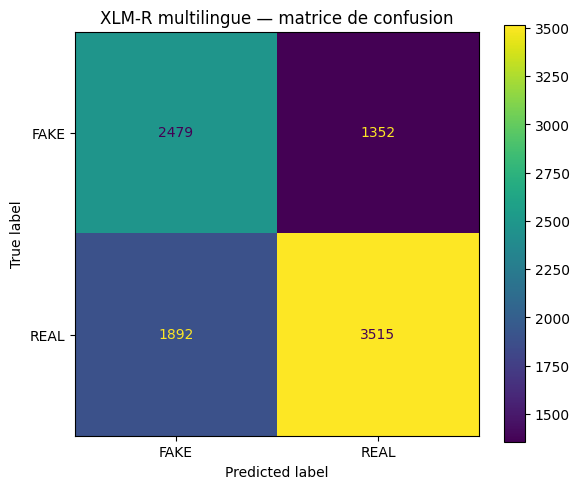

,text,label_binary,dataset,language,split,text_norm,label,prediction,confidence
2043,«القابضة للغزل» توقع مع «أوراسكوم للإنشاءات» ع...,REAL,AFND,ar,test,«القابضة للغزل» توقع مع «أوراسكوم للإنشاءات» ع...,1,FAKE,0.999159
7015,المقاصة يعتمد جهاز الكرة الجديد وسراج متحدثا ر...,REAL,AFND,ar,test,المقاصة يعتمد جهاز الكرة الجديد وسراج متحدثا ر...,1,FAKE,0.999115
6845,جنايات القاهرة تقضى بحبس متهم بالاعتداء على طب...,REAL,AFND,ar,test,جنايات القاهرة تقضى بحبس متهم بالاعتداء على طب...,1,FAKE,0.999114
7381,كيف تفاعل المشاهير مع حادث التحرش بطفلة المعاد...,REAL,AFND,ar,test,كيف تفاعل المشاهير مع حادث التحرش بطفلة المعاد...,1,FAKE,0.999096
8406,عاجل تنفيذ حكم الإعدام في قاتلة الطفلة حنين مو...,REAL,AFND,ar,test,عاجل تنفيذ حكم الإعدام في قاتلة الطفلة حنين مو...,1,FAKE,0.999091
862,اليوم.. انطلاق دوري الدرجة الأولى العراقي\nالم...,FAKE,AFND,ar,test,اليوم.. انطلاق دوري الدرجة الأولى العراقي المس...,0,REAL,0.999053
1075,بعد أزمتها الأخيرة.. كيف أصبح ابن مها أحمد الأ...,REAL,AFND,ar,test,بعد أزمتها الأخيرة.. كيف أصبح ابن مها أحمد الأ...,1,FAKE,0.999051
8374,محمد صلاح يقود ليفربول أمام لايبزيج\nالمستقلة/...,FAKE,AFND,ar,test,محمد صلاح يقود ليفربول أمام لايبزيج المستقلة/-...,0,REAL,0.999040
9226,مكتب التمثيل العمالى بميلانو ينجح فى تحصيل مست...,REAL,AFND,ar,test,مكتب التمثيل العمالى بميلانو ينجح فى تحصيل مست...,1,FAKE,0.999038
9177,ضبط بلطجى يفرض إتاوات على المارة وسائقى السيار...,REAL,AFND,ar,test,ضبط بلطجى يفرض إتاوات على المارة وسائقى السيار...,1,FAKE,0.999034


,seuil,couverture,accuracy,f1_macro
0,0.5,1.000000,0.648842,0.644369
1,0.6,0.910695,0.661239,0.656295
2,0.7,0.810890,0.669470,0.663485
3,0.8,0.708703,0.678479,0.671017
4,0.9,0.583351,0.679532,0.670169


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    test_df['label_binary'], test_df['prediction'], labels=['FAKE', 'REAL'],
    values_format='d', ax=ax
)
ax.set_title('XLM-R multilingue — matrice de confusion')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'xlmr_confusion.png', dpi=160)
plt.show()

errors = test_df[test_df.label_binary != test_df.prediction].sort_values('confidence', ascending=False)
errors[['dataset', 'language', 'text', 'label_binary', 'prediction', 'confidence']].to_csv(
    RESULTS_DIR / 'xlmr_top_errors.csv', index=False
)
display(errors.head(20))

rows = []
for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:
    keep = test_df.confidence >= threshold
    if keep.sum() == 0:
        continue
    rows.append({
        'seuil': threshold,
        'couverture': keep.mean(),
        'accuracy': accuracy_score(test_df.loc[keep, 'label_binary'], test_df.loc[keep, 'prediction']),
        'f1_macro': f1_score(test_df.loc[keep, 'label_binary'], test_df.loc[keep, 'prediction'], average='macro', zero_division=0),
    })
abstention = pd.DataFrame(rows)
display(abstention)
abstention.to_csv(RESULTS_DIR / 'xlmr_confidence_abstention.csv', index=False)

## 9. Sauvegarde finale

In [13]:
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
with open(MODEL_DIR / 'label_mapping.json', 'w', encoding='utf-8') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, ensure_ascii=False, indent=2)
print('Modèle final :', MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle final : /content/drive/MyDrive/FakeNewsDetection/models/xlmr_multilingual
